# Figure 5

LSV

run at /vento (USP)

Created: 27/01/2025 

Last update: 05/06/2025 

In [86]:
import sys
sys.prefix
import numpy as np # type: ignore
import xarray as xr # type: ignore
import os, glob
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import matplotlib.dates as mdates # type: ignore
import matplotlib.ticker as ticker # type: ignore
import matplotlib.patches as mpatches  # type: ignore
from matplotlib.gridspec import GridSpec # type: ignore
import cmaps # type: ignore
from cmocean import cm # type: ignore
from shapely.geometry.polygon import LinearRing # type: ignore
from scipy import integrate # type: ignore
from scipy import stats # type: ignore
from scipy import signal # type: ignore
from scipy.stats import pearsonr # type: ignore
from scipy.stats import ttest_ind # type: ignore
import seaborn as sns # type: ignore
import cftime # type: ignore
import nc_time_axis # type: ignore
degree_sign= u'\N{DEGREE SIGN}'

In [87]:
def xr_CI(data_array, signif=0.95, dim=None):
    from scipy.stats import t # type: ignore
    """
    Calculate the confidence interval of a DataArray along a specified dimension.

    Parameters:
    data_array (xarray.DataArray): The DataArray to compute the confidence interval on.
    confidence (float): The confidence level, between 0 and 1. Default is 0.95.
    dim (str or None): The dimension along which to calculate the confidence interval. 
                       If None, will compute over the entire dataset.

    Returns:
    xarray.DataArray: A DataArray containing the lower and upper bounds of the confidence interval.
    """
    mean = data_array.mean(dim)
    std = data_array.std(dim)
    n = data_array.count(dim)
    se = std / np.sqrt(n)
    h = se * t.ppf((1 + signif) / 2., n - 1)

    lower_bound = mean - h
    upper_bound = mean + h
    return xr.Dataset({'lb': lower_bound, 'ub': upper_bound})

In [88]:
def stippling_signal_agreement(data,nivel):
    #data = tosMod #np.stack(mv_std_modelos)
    nPos=np.sum(data>=0, axis=-1) # check where the anomaly is positive (sum)
    nNeg=np.sum(data<0, axis=-1) # check where the anomaly is negative
    N = round(data.shape[1]*nivel*.01) # calculates the number of events for reference
    
    if data.dims[0] == 'time':
        scatter_x=data.time[(nPos>=N)+(nNeg>=N)] # create dots to plot (time vs. anomaly)
    elif data.dims[0] == 'year':
        scatter_x=data.year[(nPos>=N)+(nNeg>=N)] # create dots to plot (time vs. anomaly)
    if data.dims[1] == 'ensemble':
        scatter_y=data.mean('ensemble')[(nPos>=N)+(nNeg>=N)]
    elif data.dims[1] == 'record':
        scatter_y=data.mean('record')[(nPos>=N)+(nNeg>=N)]
    
    return scatter_x, scatter_y

In [89]:
def calculate_linear_trend(values): # for variable with time not year
    # Calculate linear fit coefficients
    coeffs = np.polyfit(values.time, values.values, 1)
    slope, intercept = coeffs

    # Predict values using the linear model
    model_predictions = np.polyval([slope, intercept], values.time)

    # Calculate residuals and statistical measures
    residuals = values.values - model_predictions
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((values.values - np.mean(values.values))**2)
    r_squared = 1 - (ss_res / ss_tot)
    degrees_of_freedom = len(values) - 2
    stderr = np.sqrt(ss_res / degrees_of_freedom) / np.sqrt(np.sum((values.time - np.mean(values.time))**2))
    t_stat = slope / stderr
    p_value = stats.t.sf(np.abs(t_stat), degrees_of_freedom) * 2  # two-tailed p-value

    # Output the results
    trend_line = slope * values.time + intercept
    print(f"Linear trend: slope = {slope:.3f} (units/year), intercept = {intercept:.3f}")
    print(f"R-squared: {r_squared:.3f}, p-value: {p_value:.3g}")

    return slope, intercept, r_squared, p_value, trend_line

In [90]:
def standardize(data):
    """ Standardize data to have mean=0 and std=1 """
    return (data - data.mean()) / data.std()

In [91]:
def crosscorr_stdz(datax, datay, lag=0):
    """ Cross correlation with a lag using standardized data for Pearson's r and p-value """
    # Standardizing the data
    datax = (datax - datax.mean()) / datax.std()
    datay = (datay - datay.mean()) / datay.std()
    
    # Shift and drop NaNs to ensure equal length of data
    datax_lagged = datax.shift(time=lag).dropna(dim='time', how='all')
    datay = datay.sel(time=datax_lagged.time)
    r, p = pearsonr(datax_lagged, datay)
    return r, p

In [92]:
def EUC_transport(xaraayDataSetU):
    """
    Calculate EUC transport at 23W 
    from an xarray.DataArray with dimensions time x lat x depth x record and variable called 'uo'
    integrating the eastward (positive) velocity in 0-200 m between 2°N and 2°S at 23°W (Fu et al. 2022)
    """
    earth_radius = 6371e3  # Earth's radius in meters
    deg_to_rad = np.pi / 180  # Conversion factor from degrees to radians

    # select the region for EUC rtansport
    u = xaraayDataSetU.sel(lat=slice(3,-3),depthu=slice(0,200))

    # compute lat distance in meters
    lat_distances = np.cos(u.lat * deg_to_rad) * deg_to_rad * earth_radius        

    # Mask negative velocities with zeros
    uPOS = u.uo.where(u.uo > 0, 0)

    # Multiply variable per latitude distances (not homogeneous in space)
    lat_transport = uPOS * lat_distances.values

    # Integrate over depth to get total transport
    # Ensure that depths is a 1D array with the same length as the second dimension of u_velocity
    total_transport = lat_transport.integrate("depthu")

    # Sum over all latitudes to get total transport in m^3/s
    # Convert to Sv (Sverdrups, where 1 Sv = 10^6 m^3/s)
    EUCtransport = total_transport.sum('lat')/ 1e6

    return EUCtransport

In [94]:
PathDataSets = '/bolha/wk2/laura/dataIPSLpast2k/'
PathFigures = '/home/laura/figures/STC/draft_figures/review1/'

In [95]:
slice_clim =slice('1850','1900')
clim_ref = '1850-1900'

In [96]:
plt.rcParams['font.size'] = 14

## * Annual equatorial upwelling rate

In [97]:
VhPath = '/bolha/wk2/laura/dataIPSLpast2k/vo/vo_Omon_MLD_CM65-LR-past2k-all_gr_050001-201412.nc'
dsVh = xr.open_dataset(VhPath)
vH = dsVh.vo.groupby('time.year').mean('time') # annual averages
H = dsVh.mld.groupby('time.year').mean('time') # annual averages
UhPath = '/bolha/wk2/laura/dataIPSLpast2k/uo/uo_Omon_MLD_CM65-LR-past2k-all_gr_050001-201412.nc'
dsUh = xr.open_dataset(UhPath)
uH = dsUh.uo.groupby('time.year').mean('time') # annual averages
WhPath = '/bolha/wk2/laura/dataIPSLpast2k/wo/wo_Omon_MLD_CM65-LR-past2k-all_gr_050001-201412.nc'
dsWh = xr.open_dataset(WhPath)
wH = dsWh.wo.groupby('time.year').mean('time') # annual averages
lat = dsVh.lat
lon = dsVh.lon

In [98]:
# Compute the gradient of H with respect to latitude and longitude
# Convert degrees to radians for gradient calculation
lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)

# Calculate the change in meters for a degree change in latitude and longitude
radius_earth = 6371e3  # in meters
delta_x = np.cos(lat_rad) * np.pi/180 * radius_earth
delta_y = np.pi/180 * radius_earth

# Compute gradients (approximate, using central differences for interior points)
grad_H_x = H.diff('lon') / delta_x 
grad_H_y = H.diff('lat') / delta_y  # Change in H per meter in the y (north-south) direction

# Since we lost one point in the gradient calculation, adjust the velocity arrays accordingly
uH_adjusted = uH[:, :, 1:,:]  # Adjust for the lost longitude point in grad_H_x
vH_adjusted = vH[:, 1:, :,:]  # Adjust for the lost latitude point in grad_H_y
wH_adjusted = wH[:, 1:, 1:,:]  # Adjust for both

# Dot product VH * ∇H, assuming grad_H_x and grad_H_y align with uH and vH directions respectively
dot_product = (uH_adjusted * grad_H_x) + (vH_adjusted * grad_H_y)

# Calculate S_ann = -(VH . ∇H + wH)
S_ann_mS = -(dot_product + wH_adjusted)

# Convert from m/s to m/yr
S_ann_mYr = S_ann_mS * 60 * 60 * 24 * 365.25

# Rename year to time
S_ann_mYr2 = S_ann_mYr.rename({"year": "time"})

In [99]:
# Equatorial upwelling
AtlanticUpwelling = S_ann_mYr2.sel(lat=slice(6,-6)).where(S_ann_mYr2 < 0).mean(dim=['lat','lon'])

Aup = AtlanticUpwelling - AtlanticUpwelling.sel(time=slice_clim).mean('time') # anomaly
anomAtlanticUpwelling_smooth = -1*Aup.rolling(time=10).mean().rolling(time=10).mean() # multiplies -1 to make it positive
anomAtlanticUpwelling_smooth2 = anomAtlanticUpwelling_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anom_upwell_std = anomAtlanticUpwelling_smooth.mean('record').std('time')
anom_upwell_avg = anomAtlanticUpwelling_smooth.mean('record').mean('time')

anomAtlanticUpwelling_conf = xr_CI(anomAtlanticUpwelling_smooth, signif=0.95, dim='record')
slopeUP, intercept, r_squared, p_value, trend_lineUP = calculate_linear_trend(anomAtlanticUpwelling_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )
val1850 = trend_lineUP.sel(time=1850, method="nearest")
val2015 = trend_lineUP.sel(time=2015, method="nearest")
print(f"Upwelling Value 1850: {val1850.values}, value 2015 {val2015.values}")
delta = val2015 - val1850
print(f"Absolute change in Ssub from 1850 to 2015: {delta.values}")

Linear trend: slope = -0.027 (units/year), intercept = 52.246
R-squared: 0.202, p-value: 1.44e-09
Upwelling Value 1850: 2.119415331420157, value 2015 -2.324205199323586
Absolute change in Ssub from 1850 to 2015: -4.443620530743743


In [100]:
# trends 1920-2015 
SHORTslopeUP, SHORTintercept, SHORTr_squared, SHORTp_value, SHORTtrend_lineUP = calculate_linear_trend(anomAtlanticUpwelling_smooth2.mean('record').sel(time=slice(1920,2015)).dropna(dim='time') )
val1920 = SHORTtrend_lineUP.sel(time=1920, method="nearest")
val2015 = SHORTtrend_lineUP.sel(time=2015, method="nearest")
print(f"Upwelling Value 1920: {val1920.values}, value 2015 {val2015.values}")
delta = val2015 - val1920
print(f"Absolute change in Ssub from 1920 to 2015: {delta.values}")

Linear trend: slope = -0.087 (units/year), intercept = 170.036
R-squared: 0.547, p-value: 1.14e-17
Upwelling Value 1920: 3.7635270511152896, value 2015 -4.37689298745957
Absolute change in Ssub from 1920 to 2015: -8.14042003857486


## * EUC time series

In [101]:
dsUO = xr.open_dataset(PathDataSets+'uo/uo_Omon_AtlMerid23W_CM65-LR-past2k-all_gr_050001-201412.nc')
# transport
ds_EUC = EUC_transport(dsUO)
# anomaly
anomEUC = ds_EUC.groupby('time.month') - ds_EUC.sel(time=slice_clim).groupby('time.month').mean('time')
anomEUC_smooth = anomEUC.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
anomEUC_smooth2 = anomEUC_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomEUC_conf = xr_CI(anomEUC_smooth, signif=0.95, dim='record')
anomEUC_std = anomEUC_smooth.mean('record').std('time')
anomEUC_avg = anomEUC_smooth.mean('record').mean('time')

slopeEUC, intercept, r_squared, p_value, trend_lineEUC = calculate_linear_trend(anomEUC_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )
val1850 = trend_lineEUC.sel(time=1850, method="nearest")
val2015 = trend_lineEUC.sel(time=2015, method="nearest")
print(f"EUC Value 1850: {val1850.values}, value 2015 {val2015.values}")
delta = val2015 - val1850
print(f"Absolute change in Ssub from 1850 to 2015: {delta.values}")

Linear trend: slope = -0.001 (units/year), intercept = 1.415
R-squared: 0.084, p-value: 0.000167
EUC Value 1850: 0.08406307099255916, value 2015 -0.033964705948358986
Absolute change in Ssub from 1850 to 2015: -0.11802777694091815


In [102]:
# trends 1920-2015 
SHORTslopeEUC, SHORTintercept, SHORTr_squared, SHORTp_value, SHORTtrend_lineEUC = calculate_linear_trend(anomEUC_smooth2.mean('record').sel(time=slice(1920,2015)).dropna(dim='time') )

Linear trend: slope = -0.003 (units/year), intercept = 5.570
R-squared: 0.371, p-value: 5.76e-11


In [103]:
corr_coef, pvalue = stats.pearsonr(anomEUC_smooth.mean('record').sel(time=slice('0500','2015')).dropna(dim='time'),
                                    anomAtlanticUpwelling_smooth.mean('record').sel(time=slice('0500','2015')).dropna(dim='time'))
print(f"Past2k EUC vs. UPWELLING: R = {round(corr_coef,3)} (sig p-value <0.5)")

Past2k EUC vs. UPWELLING: R = 0.742 (sig p-value <0.5)


## * Thermocline transports

In [104]:
dsVOn = xr.open_dataset(PathDataSets+'vo/vo_Omon_AtlZonalAvgNorth_CM65-LR-past2k-all_gr_050001-201412_exac10N.nc')
dsVOs = xr.open_dataset(PathDataSets+'vo/vo_Omon_AtlZonalAvgSouth_CM65-LR-past2k-all_gr_050001-201412_exac10S.nc')
dsMLD = xr.open_dataset(PathDataSets+'mld/mld_Omon_CM65-LR-past2k-all_gr_050001-201412.nc')
dsTHCD = xr.open_dataset(PathDataSets+'thcd/thcd_Omon_CM65-LR-past2k-all_gr_050001-201412.nc')
dsTHCD = dsTHCD.rename({'rho': 'thcd'})

## lat sections
latNorth1, latNorth2 = 11, 9
latSouth1, latSouth2 = -9,-11

# Select lats for MLDs and THCD 
MLDs = dsMLD.sel(lat=slice(latSouth1,latSouth2)).mean('lat')
THCDs = dsTHCD.sel(lat=slice(latSouth1,latSouth2)).mean('lat')
MLDn = dsMLD.sel(lat=slice(latNorth1,latNorth2)).mean('lat')
THCDn = dsTHCD.sel(lat=slice(latNorth1,latNorth2)).mean('lat')

In [105]:
# 10N
# Select v between MLD and THCD for all times and records
shape = (len(MLDn.time), len(MLDn.lon), len(MLDn.record))
Vn_mldTHCD = xr.full_like(dsVOn, np.nan)

# Iterate and apply conditions
for r in MLDn.record.values:
    for lon in MLDn.lon.values:
        # Extracting the MLD and THCM values for the current record and longitude
        mld_values = MLDn.mld.sel(lon=lon, record=r)
        thcm_values = THCDn.thcd.sel(lon=lon, record=r)

        # Extract the corresponding section of the Vs dataset
        voN = dsVOn.sel(lon=lon, record=r)

        # Applying the condition across the depth dimension
        condition = (voN.depthv > mld_values) & (voN.depthv <= thcm_values)

        # Where the condition is True, replace the corresponding values in the pre-allocated array
        Vn_mldTHCD.loc[dict(lon=lon, record=r)] = voN.where(condition)

# Integrate in the depth (first fill nan with zero)
Vn_mldTHCD_filled = Vn_mldTHCD.fillna(0)

# select pos and neg
ipslVnPOS_mldTHCD = Vn_mldTHCD_filled.where(Vn_mldTHCD_filled > 0, 0)
ipslVnNEG_mldTHCD = Vn_mldTHCD_filled.where(Vn_mldTHCD_filled < 0, 0)

# integrate in the vertical
Vn_intVertPOS = ipslVnPOS_mldTHCD.integrate("depthv")
Vn_intVertNEG = ipslVnNEG_mldTHCD.integrate("depthv")
Vn_intVert = Vn_mldTHCD_filled.integrate("depthv") # total

# Calculate the width of each longitude cell in meters in a latitude (Assume regular grid spacing in longitude)
earth_radius = 6371e3
dlon_rad = np.abs(np.diff(dsVOn.lon) * np.pi / 180).mean()
lon_width = dlon_rad * earth_radius * np.cos(10 * np.pi / 180) # 10 is the latitude of the section

# Multiplies by the longitude width (in meters)
meridional_transportNpos = (Vn_intVertPOS * lon_width)/1e6
meridional_transportNneg = (Vn_intVertNEG * lon_width)/1e6
meridional_transportN = (Vn_intVert * lon_width)/1e6

# Anomaly 
anomTRANSPnPOS = meridional_transportNpos.groupby('time.month') - meridional_transportNpos.sel(time=slice_clim).groupby('time.month').mean('time')
anomTRANSPnNEG = meridional_transportNneg.groupby('time.month') - meridional_transportNneg.sel(time=slice_clim).groupby('time.month').mean('time')
anomTRANSPn = meridional_transportN.groupby('time.month') - meridional_transportN.sel(time=slice_clim).groupby('time.month').mean('time')

In [106]:
# 10S
# Select v between MLD and THCD for all times and records
shape = (len(MLDs.time), len(MLDs.lon), len(MLDs.record))
Vs_mldTHCD = xr.full_like(dsVOs, np.nan)

# Iterate and apply conditions
for r in MLDs.record.values:
    for lon in MLDs.lon.values:
        # Extracting the MLD and THCM values for the current record and longitude
        mld_values = MLDs.mld.sel(lon=lon, record=r)
        thcm_values = THCDs.thcd.sel(lon=lon, record=r)

        # Extract the corresponding section of the Vs dataset
        voS = dsVOs.sel(lon=lon, record=r)

        # Applying the condition across the depth dimension
        condition = (voS.depthv > mld_values) & (voS.depthv <= thcm_values)

        # Where the condition is True, replace the corresponding values in the pre-allocated array
        Vs_mldTHCD.loc[dict(lon=lon, record=r)] = voS.where(condition)

# Integrate in the depth (first fill nan with zero)
Vs_mldTHCD_filled = Vs_mldTHCD.fillna(0)

# select pos and neg
ipslVsPOS_mldTHCD = Vs_mldTHCD_filled.where(Vs_mldTHCD_filled > 0, 0)
ipslVsNEG_mldTHCD = Vs_mldTHCD_filled.where(Vs_mldTHCD_filled < 0, 0)

# integrate in the vertical
Vs_intVertPOS = ipslVsPOS_mldTHCD.integrate("depthv")
Vs_intVertNEG = ipslVsNEG_mldTHCD.integrate("depthv")
Vs_intVert = Vs_mldTHCD_filled.integrate("depthv") # total

# Calculate the width of each longitude cell in meters in a latitude (Assume regular grid spacing in longitude)
earth_radius = 6371e3
dlon_rad = np.abs(np.diff(dsVOs.lon) * np.pi / 180).mean()
lon_width = dlon_rad * earth_radius * np.cos(10 * np.pi / 180) # 10 is the latitude of the section

# Multiplies by the longitude width (in meters)
meridional_transportSpos = (Vs_intVertPOS * lon_width)/1e6
meridional_transportSneg = (Vs_intVertNEG * lon_width)/1e6
meridional_transportS = (Vs_intVert * lon_width)/1e6

# Anomaly 
anomTRANSPsPOS = meridional_transportSpos.groupby('time.month') - meridional_transportSpos.sel(time=slice_clim).groupby('time.month').mean('time')
anomTRANSPsNEG = meridional_transportSneg.groupby('time.month') - meridional_transportSneg.sel(time=slice_clim).groupby('time.month').mean('time')
anomTRANSPs = meridional_transportS.groupby('time.month') - meridional_transportS.sel(time=slice_clim).groupby('time.month').mean('time')


In [107]:
# net transport anomaly for each sector (colored arrows on fig avg) + Sectors as Fu et al. 2022

############################ 10N
# WB (55W to 25W)
lon_slice = slice(-65,-55)
VN_WBCtransp_mldTHCD = -1*meridional_transportN.sel(lon=lon_slice).sum('lon') 
anomVN_WBCtransp_mldTHCD = anomTRANSPn.sel(lon=lon_slice).sum('lon') 
anomVN_WBCtransp_mldTHCD_smooth = -1*anomVN_WBCtransp_mldTHCD.vo.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
anomVN_WBCtransp_mldTHCD_smooth2 = anomVN_WBCtransp_mldTHCD_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomVN_WBC_conf = xr_CI(anomVN_WBCtransp_mldTHCD_smooth, signif=0.95, dim='record')
#slopeN_WBC, intercept, r_squared, p_value, trend_lineN_WBC = calculate_linear_trend(anomVN_WBCtransp_mldTHCD_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )

# INT (55W to 25W)
lon_slice = slice(-55,-25)
VN_INTERIORtransp_mldTHCD = -1*meridional_transportN.sel(lon=lon_slice).sum('lon') 
anomVN_INTERIORtransp_mldTHCD = anomTRANSPn.sel(lon=lon_slice).sum('lon') 
anomVN_INTERIORtransp_mldTHCD_smooth = -1*anomVN_INTERIORtransp_mldTHCD.vo.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
anomVN_INTERIORtransp_mldTHCD_smooth2 = anomVN_INTERIORtransp_mldTHCD_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomVN_INTERIOR_conf = xr_CI(anomVN_INTERIORtransp_mldTHCD_smooth, signif=0.95, dim='record')
#lopeN_INT, intercept, r_squared, p_value, trend_lineN_INT = calculate_linear_trend(anomVN_INTERIORtransp_mldTHCD_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )

# EB (25W to 10W)
lon_slice = slice(-25,-5)
VN_EBCtransp_mldTHCD = meridional_transportN.sel(lon=lon_slice).sum('lon') 
anomVN_EBCtransp_mldTHCD = anomTRANSPn.sel(lon=lon_slice).sum('lon') 
anomVN_EBCtransp_mldTHCD_smooth = anomVN_EBCtransp_mldTHCD.vo.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
anomVN_EBCtransp_mldTHCD_smooth2 = anomVN_EBCtransp_mldTHCD_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomVN_EBC_conf = xr_CI(anomVN_EBCtransp_mldTHCD_smooth, signif=0.95, dim='record')
#slopeN_EBC, intercept, r_squared, p_value, trend_lineN_EBC = calculate_linear_trend(anomVN_EBCtransp_mldTHCD_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )

############################ 10S
# WB (65W to 32W)
lon_slice = slice(-65,-32)
VS_WBCtransp_mldTHCD = meridional_transportS.sel(lon=lon_slice).sum('lon') 
anomVS_WBCtransp_mldTHCD = anomTRANSPs.sel(lon=lon_slice).sum('lon') 
anomVS_WBCtransp_mldTHCD_smooth = anomVS_WBCtransp_mldTHCD.vo.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
anomVS_WBCtransp_mldTHCD_smooth2 = anomVS_WBCtransp_mldTHCD_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomVS_WBC_conf = xr_CI(anomVS_WBCtransp_mldTHCD_smooth, signif=0.95, dim='record')
#slopeS_WBC, intercept, r_squared, p_value, trend_lineS_WBC = calculate_linear_trend(anomVS_WBCtransp_mldTHCD_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )

# INT (32W to 5E)
lon_slice = slice(-32,5)
VS_INTERIORtransp_mldTHCD = meridional_transportS.sel(lon=lon_slice).sum('lon') 
anomVS_INTERIORtransp_mldTHCD = anomTRANSPs.sel(lon=lon_slice).sum('lon') 
anomVS_INTERIORtransp_mldTHCD_smooth = anomVS_INTERIORtransp_mldTHCD.vo.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
anomVS_INTERIORtransp_mldTHCD_smooth2 = anomVS_INTERIORtransp_mldTHCD_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomVS_INTERIOR_conf = xr_CI(anomVS_INTERIORtransp_mldTHCD_smooth, signif=0.95, dim='record')
#slopeS_INT, intercept, r_squared, p_value, trend_lineS_INT = calculate_linear_trend(anomVS_INTERIORtransp_mldTHCD_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )

# EB (5E to 10E)
lon_slice = slice(5,10)
VS_EBCtransp_mldTHCD = -1*meridional_transportS.sel(lon=lon_slice).sum('lon') 
anomVS_EBCtransp_mldTHCD = anomTRANSPs.sel(lon=lon_slice).sum('lon') 
anomVS_EBCtransp_mldTHCD_smooth = -1*anomVS_EBCtransp_mldTHCD.vo.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
anomVS_EBCtransp_mldTHCD_smooth2 = anomVS_EBCtransp_mldTHCD_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomVS_EBC_conf = xr_CI(anomVS_EBCtransp_mldTHCD_smooth, signif=0.95, dim='record')
#slopeS_EBC, intercept, r_squared, p_value, trend_lineS_EBC = calculate_linear_trend(anomVS_EBCtransp_mldTHCD_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )

## * Thermocline convergences and divergence

In [108]:
# WB convergence anomaly
THCD_WB_conv = abs(VN_WBCtransp_mldTHCD) + abs(VS_WBCtransp_mldTHCD)
anomTHCD_WB_conv = THCD_WB_conv.groupby('time.month') - THCD_WB_conv.sel(time=slice_clim).groupby('time.month').mean('time')
anomTHCD_WB_conv_smooth = anomTHCD_WB_conv.vo.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
anomTHCD_WB_conv_smooth2 = anomTHCD_WB_conv_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomWB_conf = xr_CI(anomTHCD_WB_conv_smooth, signif=0.95, dim='record') # CI
WB_std = anomTHCD_WB_conv_smooth.mean('record').std('time')
WB_avg = anomTHCD_WB_conv_smooth.mean('record').mean('time')
#slope_WBconv, intercept, r_squared, p_value, trend_line_WBconv = calculate_linear_trend(anomTHCD_WB_conv_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )

# INT convergence anomaly
THCD_INT_conv = abs(VN_INTERIORtransp_mldTHCD) + abs(VS_INTERIORtransp_mldTHCD)
anomTHCD_INT_conv = THCD_INT_conv.groupby('time.month') - THCD_INT_conv.sel(time=slice_clim).groupby('time.month').mean('time')
anomTHCD_INT_conv_smooth = anomTHCD_INT_conv.vo.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
anomTHCD_INT_conv_smooth2 = anomTHCD_INT_conv_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomINT_conf = xr_CI(anomTHCD_INT_conv_smooth, signif=0.95, dim='record') # CI
INT_std = anomTHCD_INT_conv_smooth.mean('record').std('time')
INT_avg = anomTHCD_INT_conv_smooth.mean('record').mean('time')
#slope_INTconv, intercept, r_squared, p_value, trend_line_INTconv = calculate_linear_trend(anomTHCD_INT_conv_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )

# EB divergence anomaly
THCD_EB_div = abs(VN_EBCtransp_mldTHCD) + abs(VS_EBCtransp_mldTHCD)
anomTHCD_EB_div = THCD_EB_div.groupby('time.month') - THCD_EB_div.sel(time=slice_clim).groupby('time.month').mean('time')
anomTHCD_EB_div_smooth = anomTHCD_EB_div.vo.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean()
anomTHCD_EB_div_smooth2 = anomTHCD_EB_div_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomEB_conf = xr_CI(anomTHCD_EB_div_smooth, signif=0.95, dim='record') # CI
EB_std = anomTHCD_EB_div_smooth.mean('record').std('time')
EB_avg = anomTHCD_EB_div_smooth.mean('record').mean('time')
#slope_EBdiv, intercept, r_squared, p_value, trend_line_EBdiv = calculate_linear_trend(anomTHCD_EB_div_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )


## * Lag correlations EUC vs WB, INT convergence

In [109]:
PreInd_THCD_INT_conv_smooth2 = anomTHCD_INT_conv_smooth2.mean('record').sel(time=slice('0500','1850')).dropna(dim='time')
PreInd_THCD_WB_conv_smooth2 = anomTHCD_WB_conv_smooth2.mean('record').sel(time=slice('0500','1850')).dropna(dim='time')
PreInd_anomEUC_smooth2 = anomEUC_smooth2.mean('record').sel(time=slice('0500','1850')).dropna(dim='time')
PreInd_anomAtlanticUpwelling_smooth2 = anomAtlanticUpwelling_smooth2.mean('record').sel(time=slice('0500','1850')).dropna(dim='time')

PosInd_THCD_INT_conv_smooth2 = anomTHCD_INT_conv_smooth2.mean('record').sel(time=slice('1850','2015')).dropna(dim='time')
PosInd_THCD_WB_conv_smooth2 = anomTHCD_WB_conv_smooth2.mean('record').sel(time=slice('1850','2015')).dropna(dim='time')
PosInd_anomEUC_smooth2 = anomEUC_smooth2.mean('record').sel(time=slice('1850','2015')).dropna(dim='time')
PosInd_anomAtlanticUpwelling_smooth2 = anomAtlanticUpwelling_smooth2.mean('record').sel(time=slice('1850','2015')).dropna(dim='time')

past2k_THCD_INT_conv_smooth2 = anomTHCD_INT_conv_smooth2.mean('record').dropna(dim='time')
past2k_THCD_WB_conv_smooth2 = anomTHCD_WB_conv_smooth2.mean('record').dropna(dim='time')
past2k_anomEUC_smooth2 = anomEUC_smooth2.mean('record').dropna(dim='time')
past2k_anomAtlanticUpwelling_smooth2 = anomAtlanticUpwelling_smooth2.mean('record').dropna(dim='time')

In [110]:
# EUC vs others
EUCvariables1 = {
    "EUC pre-ind": PreInd_anomEUC_smooth2,
    "EUC past2k": past2k_anomEUC_smooth2,   
}

CONVvariables2 = {
    "THCD CONV INT pre-ind": PreInd_THCD_INT_conv_smooth2,
    "THCD CONV INT past2k": past2k_THCD_INT_conv_smooth2,
    "THCD CONV WB pre-ind": PreInd_THCD_WB_conv_smooth2, 
    "THCD CONV WB past2k": past2k_THCD_WB_conv_smooth2,
}

# Specific pairs to analyze
EUCandCONVspecific_pairs = [
                  ("EUC past2k","THCD CONV WB past2k","WB  past2k",'#6B21A8'),
                  ("EUC pre-ind","THCD CONV WB pre-ind","WB pre-ind",'#C084FC'),

                  ("EUC past2k","THCD CONV INT past2k","INT past2k", '#166534' ),
                  ("EUC pre-ind","THCD CONV INT pre-ind","INT pre-ind", '#9BCF9B'),
                  ]

# Parameters for lag range
max_lag_years = 50

# Initialize results storage
EUCandCONVresults = []

## * Lag correlations Eq upwelling vs WB, INT convergence

In [111]:
# Upwelling vs others
UPWELLvariables1 = {
    "Up pre-ind": PreInd_anomAtlanticUpwelling_smooth2,
    "Up past2k": past2k_anomAtlanticUpwelling_smooth2,  
}

CONVvariables2 = {
    "THCD CONV INT pre-ind": PreInd_THCD_INT_conv_smooth2,
    "THCD CONV INT past2k": past2k_THCD_INT_conv_smooth2,
    "THCD CONV WB pre-ind": PreInd_THCD_WB_conv_smooth2, 
    "THCD CONV WB past2k": past2k_THCD_WB_conv_smooth2,
}

# Specific pairs to analyze
UPWELLandCONVspecific_pairs = [
                  ("Up past2k","THCD CONV WB past2k","WB conv past2k",'#6B21A8'),
                  ("Up pre-ind","THCD CONV WB pre-ind","WB conv pre-ind",'#C084FC'),

                  ("Up past2k","THCD CONV INT past2k","INT conv past2k", '#166534' ),
                  ("Up pre-ind","THCD CONV INT pre-ind","INT conv pre-ind", '#9BCF9B'),
                  ]

# Parameters for lag range
max_lag_years = 50

# Initialize results storage
UPWELLandCONVresults = []

## Figure

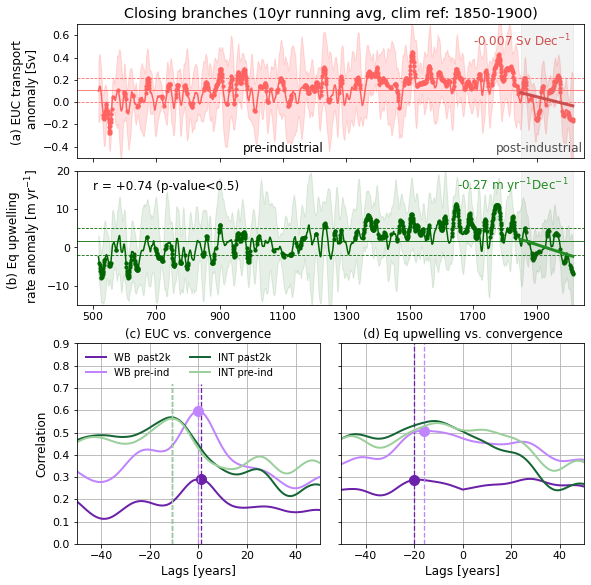

In [127]:
colorEUC = '#ff6361' 

plt.rcParams.update({"font.size": 12,"xtick.labelsize": 11,"ytick.labelsize": 11,})
fig = plt.figure(figsize=(8, 8), constrained_layout=True)
gs = fig.add_gridspec(nrows=3,ncols=2,height_ratios=[0.8, 0.8, 1.2]) #, width_ratios=[1, 1, 1.3])  

### FIRST SUBPLOT -- EUC transport
ax_EUC = fig.add_subplot(gs[0, :])      # row 0, all columns
ax_EUC.set_title('Closing branches (10yr running avg, clim ref: '+clim_ref+')')
ax_EUC.set_ylabel('(a) EUC transport \n anomaly [Sv]')
x,y = stippling_signal_agreement(anomEUC_smooth2,80)
ax_EUC.axhline(y=anomEUC_avg, c=colorEUC,lw=.8)
ax_EUC.axhline(y=anomEUC_avg+anomEUC_std, c=colorEUC,lw=.8,ls='--')
ax_EUC.axhline(y=anomEUC_avg-anomEUC_std, c=colorEUC,lw=.8,ls='--')
ax_EUC.fill_between(range(500,2015), anomEUC_conf.lb, anomEUC_conf.ub, color=colorEUC, alpha=.2)
ax_EUC.plot(range(500,2015), anomEUC_smooth.mean('record') ,c=colorEUC)
ax_EUC.scatter(x[1:],y[1:], color=colorEUC, marker='o', s=10, edgecolors=colorEUC) # stippling where the anomaly agrees on signal
ax_EUC.plot(range(1850,2015), trend_lineEUC, color='#cc4f4d',lw=3)
ax_EUC.text(1700, .5, f"{round(slopeEUC*10, 3)} Sv Dec$^{{-1}}$", color='#cc4f4d', fontsize=12)

ax_EUC.set_ylim(-.5,.7)
ax_EUC.set_xlim(450,2050)
ax_EUC.set_xticks(np.arange(500,2014,200))
ax_EUC.text(1100,-0.45,'pre-industrial',color='k',ha='center')
ax_EUC.axvspan(1852, 2015, alpha=0.1, color='gray')
ax_EUC.text(1910,-0.45,'post-industrial',color='#4D4D4D',ha='center')
plt.setp(ax_EUC.get_xticklabels(), visible=False)


### SECOND SUBPLOT -- UPWELLING 
ax_UPWELL = fig.add_subplot(gs[1, :])
ax_UPWELL.set_ylabel('(b) Eq upwelling \n rate anomaly [m yr$^{-1}$]')
x,y = stippling_signal_agreement(anomAtlanticUpwelling_smooth,80)
ax_UPWELL.axhline(y=anom_upwell_avg, c='darkgreen',lw=.8)
ax_UPWELL.axhline(y=anom_upwell_avg+anom_upwell_std, c='darkgreen',lw=.8,ls='--')
ax_UPWELL.axhline(y=anom_upwell_avg-anom_upwell_std, c='darkgreen',lw=.8,ls='--')
ax_UPWELL.fill_between(range(500,2015), anomAtlanticUpwelling_conf.lb, anomAtlanticUpwelling_conf.ub, color='darkgreen', alpha=.1)
ax_UPWELL.plot(range(500,2015), anomAtlanticUpwelling_smooth.mean('record'),c='darkgreen',label='Equatorial 5N-5S')
ax_UPWELL.scatter(x[1:],y[1:], color='darkgreen', marker='o', s=10, edgecolors='darkgreen') # stippling where the anomaly agrees on signal
ax_UPWELL.plot(range(1850,2015), trend_lineUP, color='#228B22',lw=3)
ax_UPWELL.text(1650, 15, f"{round(slopeUP*10, 2)} m yr$^{{-1}}$Dec$^{{-1}}$", color='#228B22', fontsize=12)

ax_UPWELL.text(500, 15, f"r = +{round(corr_coef, 2)} (p-value<0.5)")

ax_UPWELL.set_ylim(-15,20.1)
ax_UPWELL.set_xlim(450,2050)
ax_UPWELL.set_xticks(np.arange(500,2014,200))
ax_UPWELL.axvspan(1852, 2015, alpha=0.1, color='gray')


### THIRD SUBPLOT -- CORR EUC VS CONV
ax_EUCconv = fig.add_subplot(gs[2, 0])
for i, (var1_name, var2_name, name_label, cor) in enumerate(EUCandCONVspecific_pairs):
    var1_data = EUCvariables1[var1_name]
    var2_data = CONVvariables2[var2_name]
    # Calculate lags and correlation
    all_lags = signal.correlation_lags(len(var1_data), len(var2_data))
    lags = all_lags[(all_lags >= -max_lag_years) & (all_lags <= max_lag_years)]
    corrs, p_values = zip(*[crosscorr_stdz(var1_data, var2_data, lag=lag) for lag in lags])
    # Plot lag vs correlation on ax_corr
    line, = ax_EUCconv.plot(lags, corrs,linestyle='-',lw=2,label=name_label,color=cor)
    # Max correlation
    max_idx = np.argmax(np.abs(corrs))
    max_corr = corrs[max_idx]
    max_p_value = p_values[max_idx]
    max_lag = lags[max_idx]
    # Correlation at zero lag
    zeroLag_idx = np.argmax(lags == 0)
    zeroLag_corr = corrs[zeroLag_idx]
    zeroLag_p_value = p_values[zeroLag_idx]
    # Vertical line at max lag
    ax_EUCconv.axvline(x=max_lag, ymin=0,ymax=0.8,color=line.get_color(),linestyle='--',linewidth=1.3)
    # Asterisk / marker at max correlation for first two pairs only
    if i < 2:
        ax_EUCconv.plot(max_lag,max_corr,'o',markersize=10,color=line.get_color())
    # Store results
    EUCandCONVresults.append({
        "Var1": var1_name,
        "Var2": var2_name,
        "MaxCorr": max_corr,
        "MaxLag": max_lag,
        "PValue": max_p_value,
        "CorrLagZero": zeroLag_corr,
        "PValueLagZero": zeroLag_p_value,
    })
# To use outside if needed
results_df = pd.DataFrame(EUCandCONVresults)

ax_EUCconv.set_xlabel('Lags [years]')
ax_EUCconv.set_xlim(-50, 50)
ax_EUCconv.set_ylim(-0, 0.9)
ax_EUCconv.set_title('(c) EUC vs. convergence',fontsize=12)
ax_EUCconv.set_ylabel('Correlation')
ax_EUCconv.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax_EUCconv.legend(frameon=False, ncol=2, loc='upper left',fontsize=10)
ax_EUCconv.grid(True)

### FOURTH SUBPLOT -- CORR UPWELL VS CONV
ax_UPWELLconv = fig.add_subplot(gs[2, 1],  sharey=ax_EUCconv)
for i, (var1_name, var2_name, name_label, cor) in enumerate(UPWELLandCONVspecific_pairs):
    var1_data = UPWELLvariables1[var1_name]
    var2_data = CONVvariables2[var2_name]
    # Calculate lags and correlation
    all_lags = signal.correlation_lags(len(var1_data), len(var2_data))
    lags = all_lags[(all_lags >= -max_lag_years) & (all_lags <= max_lag_years)]
    corrs, p_values = zip(*[crosscorr_stdz(var1_data, var2_data, lag=lag) for lag in lags])
    # Plot lag vs correlation on ax_corr
    line, = ax_UPWELLconv.plot(lags, corrs,linestyle='-',lw=2,label=name_label,color=cor)
    
    # Max correlation (1st)
    max_idx = np.argmax(np.abs(corrs))
    max_corr = corrs[max_idx]
    max_p_value = p_values[max_idx]
    max_lag = lags[max_idx]

    # Max corr (2nd)
    sorted_idx = np.argsort(np.abs(corrs))
    sort_idx = sorted_idx[-10]
    sort_corr = corrs[sort_idx]
    sort_p_value = p_values[sort_idx]
    sort_lag = lags[sort_idx]

    # Vertical line at max lag
    if 0 < i <= 1:
        ax_UPWELLconv.axvline(x=max_lag,color=line.get_color(),linestyle='--',linewidth=1.3)
    # Asterisk / marker at max correlation for first two pairs only
    if i == 1:
        ax_UPWELLconv.plot(max_lag,max_corr,'o',markersize=10,color=line.get_color())
    if i == 0:
        ax_UPWELLconv.plot(sort_lag,sort_corr,'o',markersize=10,color=line.get_color())
        ax_UPWELLconv.axvline(x=sort_lag,color=line.get_color(),linestyle='--',linewidth=1.3)

    # Store results
    UPWELLandCONVresults.append({
        "Var1": var1_name,
        "Var2": var2_name,
        "MaxCorr": max_corr,
        "MaxLag": max_lag,
        "PValue": max_p_value,
        "CorrLagZero": zeroLag_corr,
        "PValueLagZero": zeroLag_p_value,
    })
# To use outside if needed
results_df = pd.DataFrame(UPWELLandCONVresults)

ax_UPWELLconv.set_xlabel('Lags [years]')
ax_UPWELLconv.set_xlim(-50, 50)
ax_UPWELLconv.set_title('(d) Eq upwelling vs. convergence',fontsize=12)  # or whatever panel label you want
ax_UPWELLconv.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax_UPWELLconv.grid(True)
_ = plt.setp(ax_UPWELLconv.get_yticklabels(), visible=False)

fig.savefig(PathFigures+'/figure_time_series_corr_EUC_UPWELL_CONV.png', format='png', bbox_inches='tight', dpi=300,  facecolor='white')
